# Linear Algebra Geometric Approach: Eigenvalue Analysis

## Objective
Use **eigenvalue decomposition** to understand the geometric structure of features and their relationship with `perceived_stress_score`.

---

## Methodology Overview

### Core Idea
- Place features in a **coordinate space**
- Decompose the **covariance matrix** to find principal directions
- Analyze which directions are most important for explaining variance
- Examine how these directions relate to the target variable

### Mathematical Foundation

**Covariance Matrix Eigendecomposition:**

$$\text{Cov}(X) = V \Lambda V^T$$

Where:
- $\Lambda = \text{diag}(\lambda_1, \lambda_2, ..., \lambda_p)$ are **eigenvalues**
- $V = [v_1, v_2, ..., v_p]$ are **eigenvectors** (principal directions)
- Eigenvalues represent **variance explained** in each direction

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


---
## 2. Define Features and Target

In [2]:
# Define feature list (20 features)
FEATURES = [
    'daily_active_minutes_instagram',
    'likes_given_per_day',
    'comments_written_per_day',
    'time_on_feed_per_day',
    'user_engagement_score',
    'sessions_per_day',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'average_session_length_minutes',
    'stories_viewed_per_day',
    'posts_created_per_week',
    'time_on_reels_per_day',
    'time_on_messages_per_day',
    'ads_clicked_per_day',
    'time_on_explore_per_day',
    'age',
    'dms_sent_per_week',
    'diet_quality',
    'exercise_hours_per_week',
    'reels_watched_per_day'
]

# Target variable
TARGET = 'perceived_stress_score'

print(f"Number of features: {len(FEATURES)}")
print(f"Target variable: {TARGET}")

Number of features: 20
Target variable: perceived_stress_score


---
## 3. Load and Preprocess Data

In [3]:
# Load data
df = pd.read_csv('instagram_usage_lifestyle.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1547896, 58)


,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [4]:
# Handle categorical variable: diet_quality
# Use ordinal encoding (Poor=1, Fair=2, Good=3, Excellent=4)
df_processed = df.copy()

diet_quality_mapping = {
    'Poor': 1,
    'Fair': 2,
    'Average': 2,
    'Good': 3,
    'Excellent': 4
}

df_processed['diet_quality_encoded'] = df_processed['diet_quality'].map(diet_quality_mapping)

# If mapping fails, use LabelEncoder
if df_processed['diet_quality_encoded'].isna().sum() > 0:
    le = LabelEncoder()
    df_processed['diet_quality_encoded'] = le.fit_transform(df_processed['diet_quality'].astype(str))
    print(f"LabelEncoder mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    print("Ordinal encoding applied successfully!")

# Update feature list
FEATURES_ENCODED = [f if f != 'diet_quality' else 'diet_quality_encoded' for f in FEATURES]
print(f"\nEncoded features: {len(FEATURES_ENCODED)}")

LabelEncoder mapping: {'Average': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Poor': np.int64(3), 'Very poor': np.int64(4)}

Encoded features: 20


In [5]:
# Extract feature matrix X and target vector y
X = df_processed[FEATURES_ENCODED].values.astype(np.float32)
y = df_processed[TARGET].values.astype(np.float32)

# Handle missing values with median
for i in range(X.shape[1]):
    col = X[:, i]
    mask = np.isnan(col)
    if mask.sum() > 0:
        col[mask] = np.nanmedian(col)

y = np.nan_to_num(y, nan=np.nanmedian(y))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1547896, 20)
y shape: (1547896,)


In [6]:
# Standardize features (crucial for eigenvalue analysis)
# This ensures all features are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Also standardize y for correlation analysis
y_scaled = (y - y.mean()) / y.std()

print("Standardization completed!")
print(f"X_scaled mean: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}")

Standardization completed!
X_scaled mean: 0.000000, std: 1.000001


---
## 4. Covariance Matrix Analysis

The covariance matrix captures the **linear relationships** between all pairs of features.

$$\text{Cov}(X_i, X_j) = \frac{1}{n-1} \sum_{k=1}^{n} (x_{ki} - \bar{x}_i)(x_{kj} - \bar{x}_j)$$

In [7]:
# Compute covariance matrix
# For standardized data, covariance matrix = correlation matrix
cov_matrix = np.cov(X_scaled.T)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"\nCovariance matrix (first 5x5 block):")
print(np.round(cov_matrix[:5, :5], 3))

Covariance matrix shape: (20, 20)

Covariance matrix (first 5x5 block):
[[ 1.     0.981  0.943  0.975 -0.53 ]
 [ 0.981  1.     0.925  0.956 -0.511]
 [ 0.943  0.925  1.     0.919 -0.485]
 [ 0.975  0.956  0.919  1.    -0.517]
 [-0.53  -0.511 -0.485 -0.517  1.   ]]


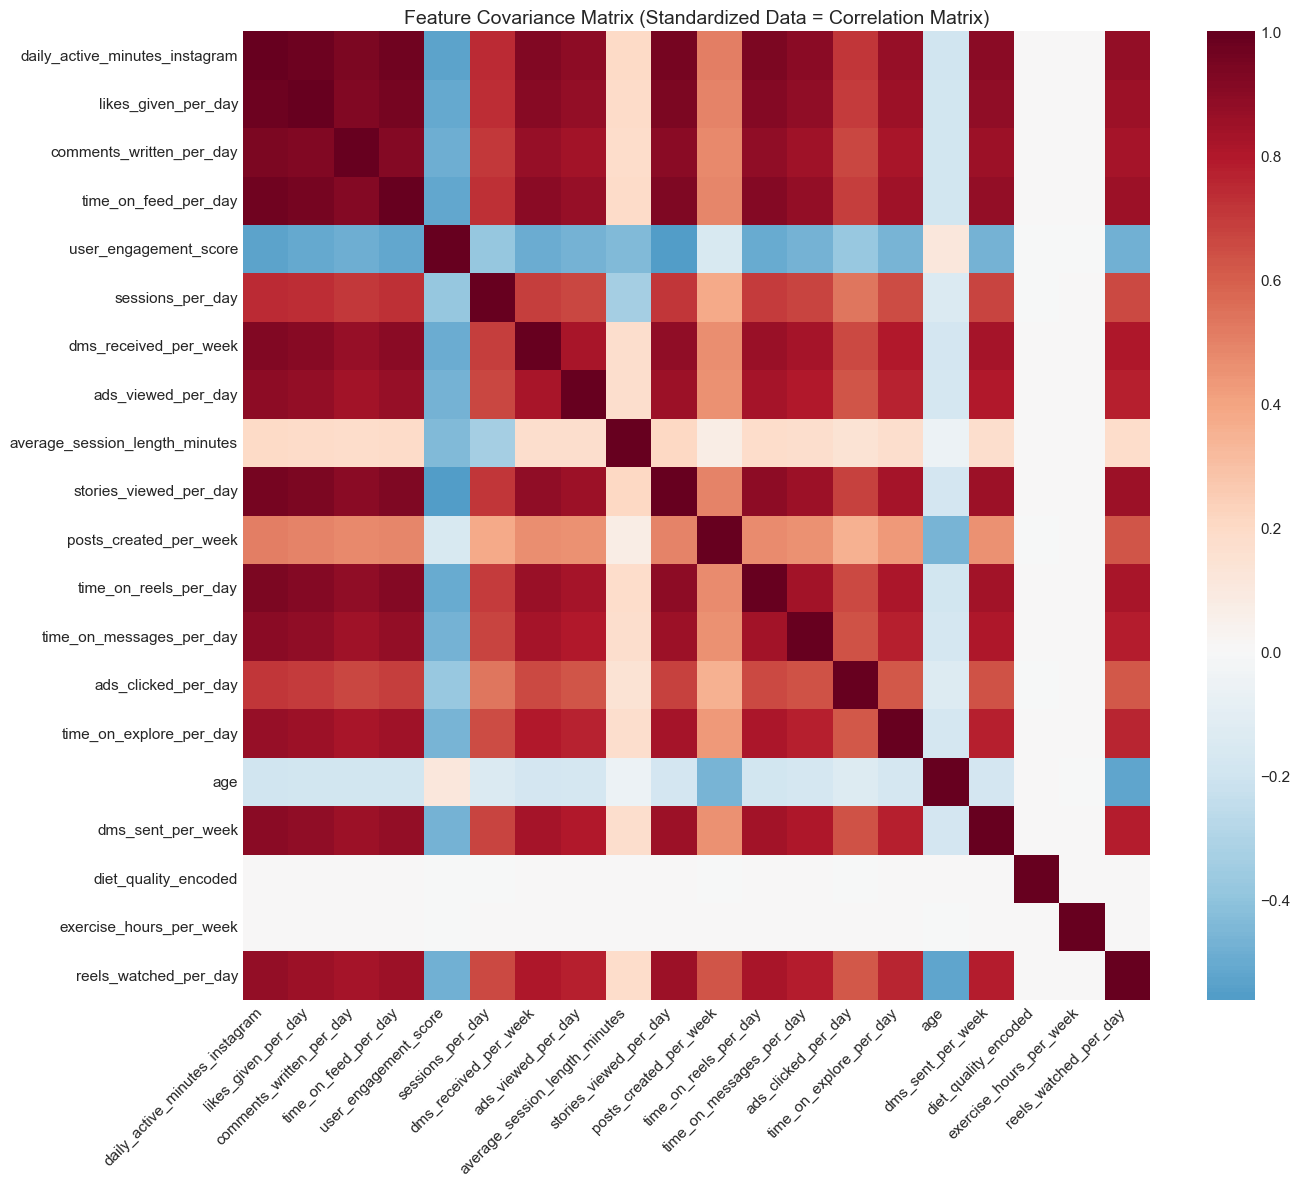

In [8]:
# Visualize covariance/correlation matrix
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
sns.heatmap(
    cov_matrix, 
    annot=False,  # Too many features for annotations
    cmap='RdBu_r', 
    center=0,
    xticklabels=FEATURES_ENCODED,
    yticklabels=FEATURES_ENCODED,
    ax=ax
)

ax.set_title('Feature Covariance Matrix (Standardized Data = Correlation Matrix)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('covariance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Eigendecomposition of Covariance Matrix

Decompose the covariance matrix to find:
- **Eigenvalues (λ)**: Amount of variance in each principal direction
- **Eigenvectors (v)**: The principal directions themselves

In [9]:
# Perform eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Eigenvalues should be real for symmetric matrices
eigenvalues = eigenvalues.real
eigenvectors = eigenvectors.real

# Sort by eigenvalue (descending order)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigendecomposition completed!")
print(f"Number of eigenvalues: {len(eigenvalues)}")

Eigendecomposition completed!
Number of eigenvalues: 20


In [10]:
# Display eigenvalues and variance explained
total_variance = eigenvalues.sum()
variance_ratio = eigenvalues / total_variance
cumulative_variance = np.cumsum(variance_ratio)

print("Eigenvalue Analysis:")
print("=" * 70)
print(f"{'PC':<6} {'Eigenvalue':<15} {'Var. Ratio (%)':<18} {'Cumulative (%)':<15}")
print("-" * 70)

for i in range(len(eigenvalues)):
    print(f"PC{i+1:<4} {eigenvalues[i]:<15.4f} {variance_ratio[i]*100:<18.2f} {cumulative_variance[i]*100:<15.2f}")

Eigenvalue Analysis:
PC     Eigenvalue      Var. Ratio (%)     Cumulative (%) 
----------------------------------------------------------------------
PC1    12.2681         61.34              61.34          
PC2    1.3965          6.98               68.32          
PC3    1.3123          6.56               74.88          
PC4    1.0006          5.00               79.89          
PC5    0.9994          5.00               84.88          
PC6    0.6438          3.22               88.10          
PC7    0.4817          2.41               90.51          
PC8    0.4358          2.18               92.69          
PC9    0.2395          1.20               93.89          
PC10   0.2014          1.01               94.90          
PC11   0.1929          0.96               95.86          
PC12   0.1717          0.86               96.72          
PC13   0.1410          0.71               97.42          
PC14   0.1215          0.61               98.03          
PC15   0.1057          0.53           

In [11]:
# Create eigenvalue summary dataframe
eigenvalue_df = pd.DataFrame({
    'Principal_Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Variance_Ratio': variance_ratio,
    'Cumulative_Variance': cumulative_variance
})

eigenvalue_df

,Principal_Component,Eigenvalue,Variance_Ratio,Cumulative_Variance
0,PC1,12.268059,0.613403,0.613403
1,PC2,1.396532,0.069827,0.683229
2,PC3,1.312308,0.065615,0.748844
3,PC4,1.000613,0.050031,0.798875
4,PC5,0.999372,0.049969,0.848844
5,PC6,0.643809,0.032190,0.881034
6,PC7,0.481681,0.024084,0.905118
7,PC8,0.435848,0.021792,0.926911
8,PC9,0.239544,0.011977,0.938888
9,PC10,0.201419,0.010071,0.948959


---
## 6. Visualize Eigenvalue Spectrum

The **scree plot** shows how variance is distributed across principal components.

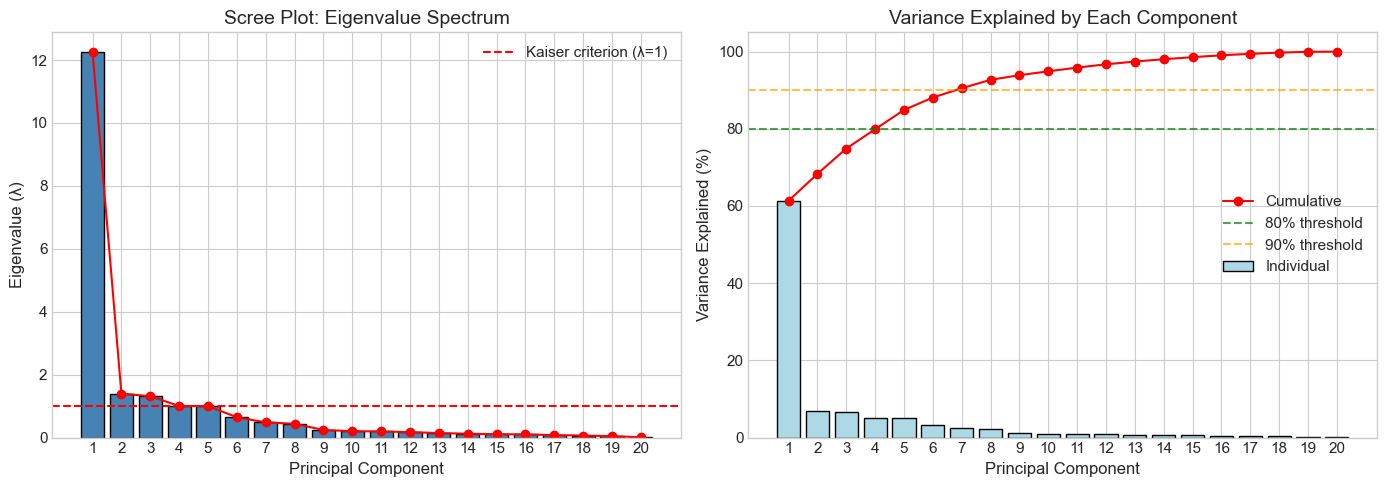


Key Findings:
  - Components needed for 80% variance: 5
  - Components needed for 90% variance: 7
  - Components with λ ≥ 1 (Kaiser criterion): 4


In [12]:
# Create scree plot and cumulative variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scree Plot (Eigenvalues)
axes[0].bar(range(1, len(eigenvalues)+1), eigenvalues, color='steelblue', edgecolor='black')
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'ro-', markersize=6)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Eigenvalue (λ)', fontsize=12)
axes[0].set_title('Scree Plot: Eigenvalue Spectrum', fontsize=14)
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# Add horizontal line at λ=1 (Kaiser criterion)
axes[0].axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (λ=1)')
axes[0].legend()

# Plot 2: Cumulative Variance Explained
axes[1].bar(range(1, len(eigenvalues)+1), variance_ratio * 100, color='lightblue', edgecolor='black', label='Individual')
axes[1].plot(range(1, len(eigenvalues)+1), cumulative_variance * 100, 'ro-', markersize=6, label='Cumulative')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Variance Explained (%)', fontsize=12)
axes[1].set_title('Variance Explained by Each Component', fontsize=14)
axes[1].set_xticks(range(1, len(eigenvalues)+1))

# Add horizontal lines at common thresholds
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].legend(loc='center right')

plt.tight_layout()
plt.savefig('eigenvalue_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# Report key findings
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_kaiser = np.sum(eigenvalues >= 1)

print(f"\nKey Findings:")
print(f"  - Components needed for 80% variance: {n_components_80}")
print(f"  - Components needed for 90% variance: {n_components_90}")
print(f"  - Components with λ ≥ 1 (Kaiser criterion): {n_kaiser}")

---
## 7. Eigenvector Analysis (Principal Directions)

Each eigenvector shows **which original features contribute to each principal direction**.

In [13]:
# Create eigenvector (loadings) dataframe
# Rows = original features, Columns = principal components
loadings_df = pd.DataFrame(
    eigenvectors,
    index=FEATURES_ENCODED,
    columns=[f'PC{i+1}' for i in range(len(eigenvalues))]
)

print("Eigenvector Loadings (first 5 PCs):")
print("=" * 70)
print("(Values show how much each feature contributes to each PC)")
print()
loadings_df.iloc[:, :5].round(3)

Eigenvector Loadings (first 5 PCs):
(Values show how much each feature contributes to each PC)



,PC1,PC2,PC3,PC4,PC5
daily_active_minutes_instagram,0.283,-0.007,0.054,0.000,0.000
likes_given_per_day,0.278,-0.004,0.054,0.000,-0.000
comments_written_per_day,0.269,-0.002,0.055,0.000,0.000
time_on_feed_per_day,0.277,-0.007,0.054,-0.000,-0.000
user_engagement_score,-0.160,0.424,-0.016,0.001,-0.000
sessions_per_day,0.217,0.396,0.179,0.001,0.004
dms_received_per_week,0.264,-0.007,0.056,-0.000,0.000
ads_viewed_per_day,0.257,-0.008,0.056,0.001,0.000
average_session_length_minutes,0.056,-0.775,-0.210,-0.000,-0.006
stories_viewed_per_day,0.273,-0.037,0.048,0.000,0.000


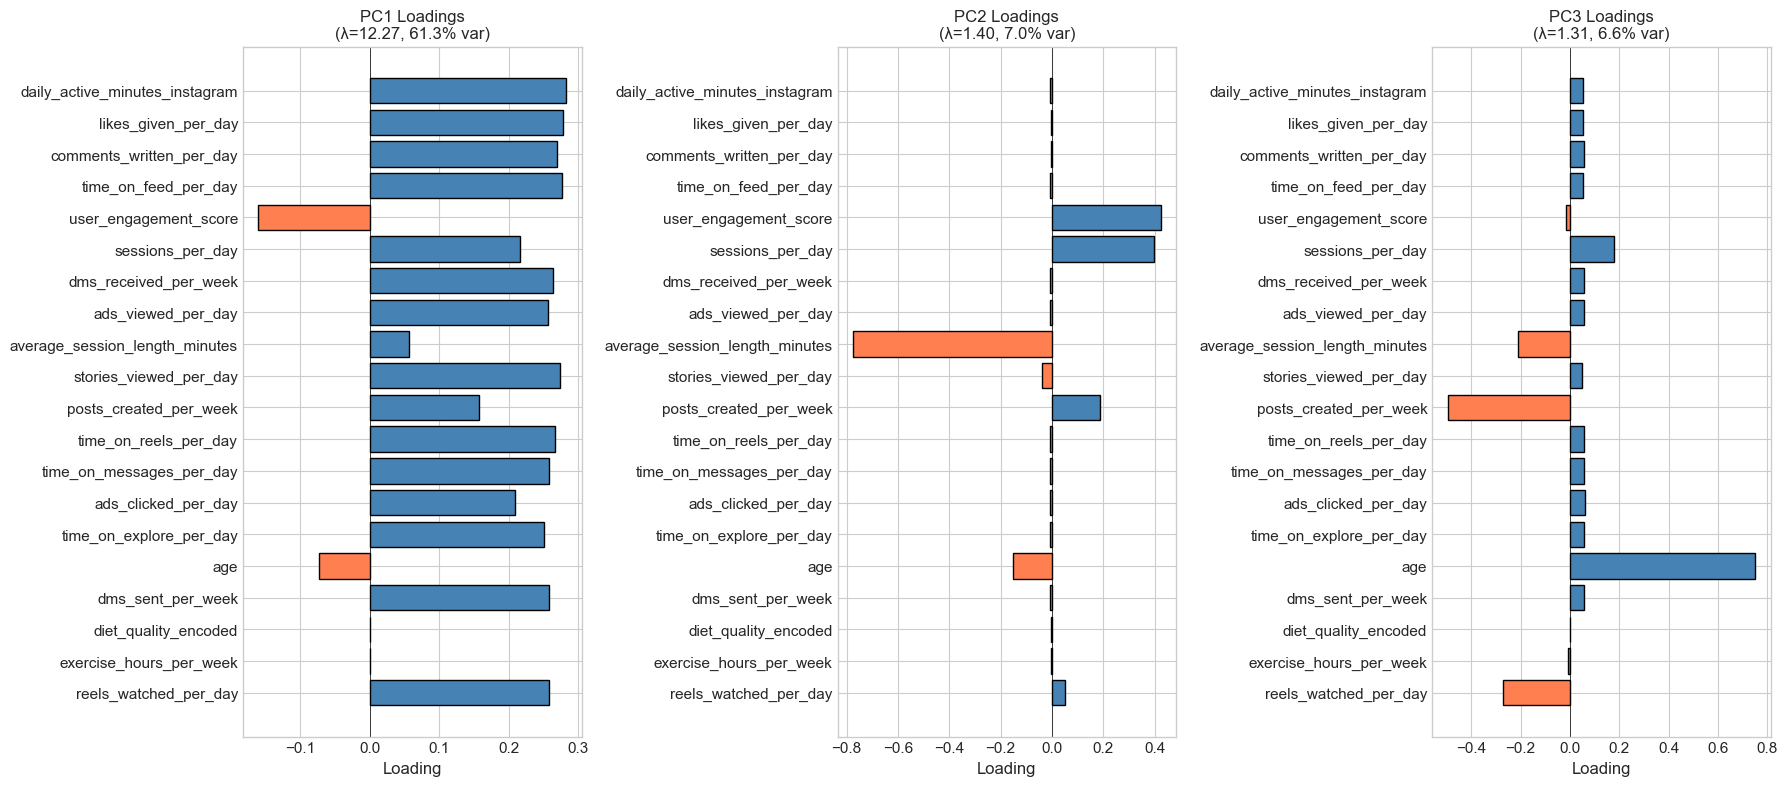

In [14]:
# Visualize loadings for first 3 principal components
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, ax in enumerate(axes):
    loadings = loadings_df[f'PC{i+1}'].values
    colors = ['steelblue' if l >= 0 else 'coral' for l in loadings]
    
    y_pos = np.arange(len(FEATURES_ENCODED))
    ax.barh(y_pos, loadings, color=colors, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(FEATURES_ENCODED)
    ax.set_xlabel('Loading', fontsize=12)
    ax.set_title(f'PC{i+1} Loadings\n(λ={eigenvalues[i]:.2f}, {variance_ratio[i]*100:.1f}% var)', fontsize=12)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('eigenvector_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Identify dominant features for each PC
print("Dominant Features for Each Principal Component:")
print("=" * 70)
print("(Features with |loading| > 0.3)")
print()

for i in range(min(5, len(eigenvalues))):  # First 5 PCs
    pc_name = f'PC{i+1}'
    loadings = loadings_df[pc_name]
    
    # Find features with high loadings
    high_loadings = loadings[np.abs(loadings) > 0.3].sort_values(key=abs, ascending=False)
    
    print(f"{pc_name} (λ={eigenvalues[i]:.3f}, {variance_ratio[i]*100:.1f}% variance):")
    for feat, load in high_loadings.items():
        direction = "+" if load > 0 else "-"
        print(f"    {direction} {feat}: {load:.3f}")
    print()

Dominant Features for Each Principal Component:
(Features with |loading| > 0.3)

PC1 (λ=12.268, 61.3% variance):

PC2 (λ=1.397, 7.0% variance):
    - average_session_length_minutes: -0.775
    + user_engagement_score: 0.424
    + sessions_per_day: 0.396

PC3 (λ=1.312, 6.6% variance):
    + age: 0.752
    - posts_created_per_week: -0.496

PC4 (λ=1.001, 5.0% variance):
    - diet_quality_encoded: -0.711
    + exercise_hours_per_week: 0.703

PC5 (λ=0.999, 5.0% variance):
    + exercise_hours_per_week: 0.711
    + diet_quality_encoded: 0.703



---
## 8. Project Data onto Principal Component Space

Transform original features into the new coordinate system defined by eigenvectors.

In [16]:
# Project data onto principal components
# X_pc = X_scaled @ eigenvectors
X_pc = X_scaled @ eigenvectors

print(f"Original data shape: {X_scaled.shape}")
print(f"Projected data shape: {X_pc.shape}")
print("\nData has been transformed to principal component space.")

Original data shape: (1547896, 20)
Projected data shape: (1547896, 20)

Data has been transformed to principal component space.


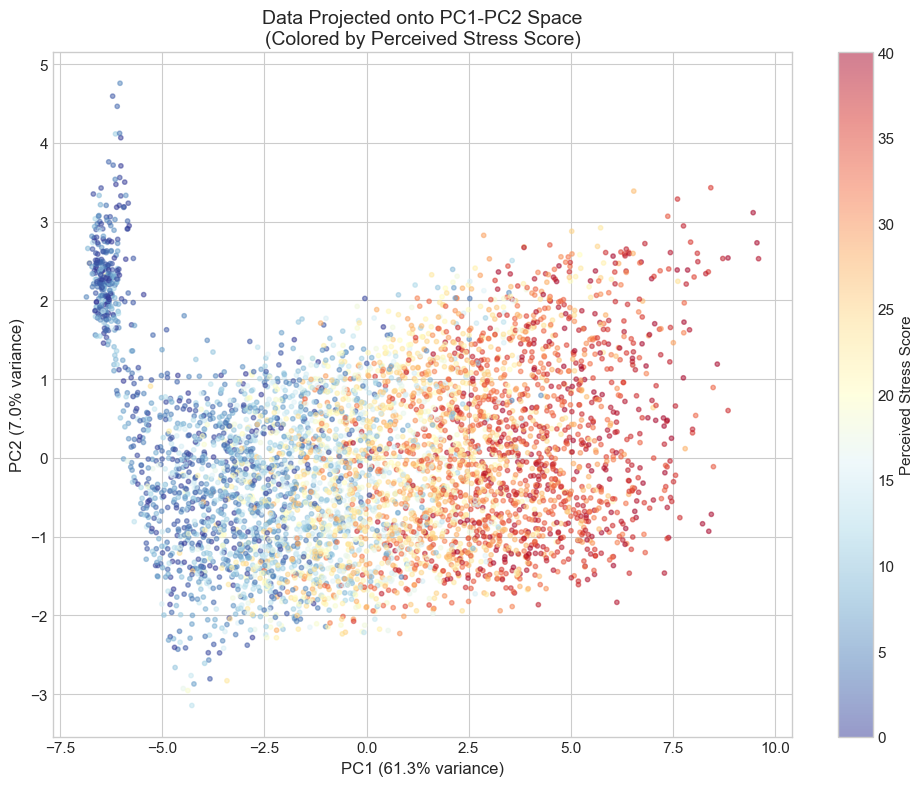

In [17]:
# Visualize data in PC1-PC2 space, colored by stress score
fig, ax = plt.subplots(figsize=(10, 8))

# Use a subset for visualization (too many points)
sample_size = min(5000, len(X_pc))
idx_sample = np.random.choice(len(X_pc), sample_size, replace=False)

scatter = ax.scatter(
    X_pc[idx_sample, 0], 
    X_pc[idx_sample, 1], 
    c=y[idx_sample], 
    cmap='RdYlBu_r', 
    alpha=0.5, 
    s=10
)

ax.set_xlabel(f'PC1 ({variance_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Data Projected onto PC1-PC2 Space\n(Colored by Perceived Stress Score)', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Perceived Stress Score', fontsize=11)

plt.tight_layout()
plt.savefig('pc_projection_2d.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Relationship Between Principal Components and Target Variable

Analyze **which principal directions are most correlated with perceived_stress_score**.

In [18]:
# Calculate correlation between each PC and target variable
pc_target_correlations = []

print("Correlation Between Principal Components and Perceived Stress Score:")
print("=" * 70)
print(f"{'PC':<8} {'Correlation (r)':<18} {'R²':<12} {'p-value':<15}")
print("-" * 70)

for i in range(len(eigenvalues)):
    r, p = stats.pearsonr(X_pc[:, i], y)
    r2 = r ** 2
    pc_target_correlations.append({'PC': f'PC{i+1}', 'r': r, 'R2': r2, 'p_value': p})
    
    # Significance indicator
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"PC{i+1:<6} {r:<18.4f} {r2:<12.4f} {p:<12.2e} {sig}")

print("-" * 70)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05")

Correlation Between Principal Components and Perceived Stress Score:
PC       Correlation (r)    R²           p-value        
----------------------------------------------------------------------
PC1      0.8181             0.6693       0.00e+00     ***
PC2      -0.0328            0.0011       0.00e+00     ***
PC3      0.1938             0.0375       0.00e+00     ***
PC4      0.0012             0.0000       1.25e-01     
PC5      -0.0002            0.0000       8.48e-01     
PC6      0.0828             0.0069       0.00e+00     ***
PC7      0.0545             0.0030       0.00e+00     ***
PC8      -0.0299            0.0009       3.04e-303    ***
PC9      -0.0166            0.0003       4.09e-95     ***
PC10     -0.0061            0.0000       2.61e-14     ***
PC11     0.0019             0.0000       1.63e-02     *
PC12     -0.0317            0.0010       0.00e+00     ***
PC13     -0.0253            0.0006       2.73e-217    ***
PC14     0.0249             0.0006       1.77e-210    ***

In [19]:
# Create correlation dataframe
pc_corr_df = pd.DataFrame(pc_target_correlations)
pc_corr_df['Abs_r'] = np.abs(pc_corr_df['r'])
pc_corr_df_sorted = pc_corr_df.sort_values('Abs_r', ascending=False)

print("\nPrincipal Components Ranked by Correlation with Stress:")
pc_corr_df_sorted


Principal Components Ranked by Correlation with Stress:


,PC,r,R2,p_value,Abs_r
0,PC1,0.818091,6.692732e-01,0.000000e+00,0.818091
2,PC3,0.193774,3.754842e-02,0.000000e+00,0.193774
5,PC6,0.082799,6.855752e-03,0.000000e+00,0.082799
19,PC20,0.058123,3.378259e-03,0.000000e+00,0.058123
6,PC7,0.054485,2.968610e-03,0.000000e+00,0.054485
14,PC15,0.043025,1.851128e-03,0.000000e+00,0.043025
16,PC17,-0.032860,1.079806e-03,0.000000e+00,0.032860
1,PC2,-0.032777,1.074323e-03,0.000000e+00,0.032777
11,PC12,-0.031673,1.003160e-03,0.000000e+00,0.031673
7,PC8,-0.029911,8.946585e-04,3.040152e-303,0.029911


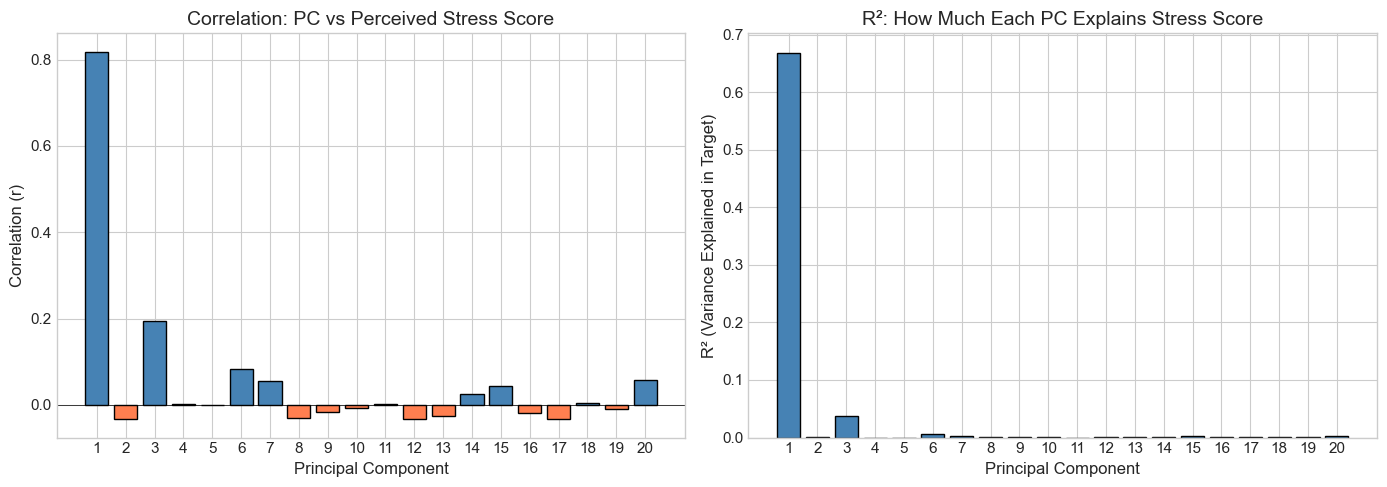

In [20]:
# Visualize PC-target correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Correlation coefficients
colors = ['steelblue' if r >= 0 else 'coral' for r in pc_corr_df['r']]
axes[0].bar(range(1, len(eigenvalues)+1), pc_corr_df['r'], color=colors, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Correlation (r)', fontsize=12)
axes[0].set_title('Correlation: PC vs Perceived Stress Score', fontsize=14)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# Plot 2: R² values (variance explained in target)
axes[1].bar(range(1, len(eigenvalues)+1), pc_corr_df['R2'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('R² (Variance Explained in Target)', fontsize=12)
axes[1].set_title('R²: How Much Each PC Explains Stress Score', fontsize=14)
axes[1].set_xticks(range(1, len(eigenvalues)+1))

plt.tight_layout()
plt.savefig('pc_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Individual Feature Correlations with Target

For comparison, analyze the **direct linear relationship** between each original feature and the target.

In [21]:
# Calculate correlation between each original feature and target
feature_correlations = []

print("Correlation Between Original Features and Perceived Stress Score:")
print("=" * 70)

for i, feat in enumerate(FEATURES_ENCODED):
    r, p = stats.pearsonr(X_scaled[:, i], y)
    feature_correlations.append({
        'Feature': feat,
        'r': r,
        'R2': r**2,
        'p_value': p
    })

# Create dataframe and sort by absolute correlation
feat_corr_df = pd.DataFrame(feature_correlations)
feat_corr_df['Abs_r'] = np.abs(feat_corr_df['r'])
feat_corr_df_sorted = feat_corr_df.sort_values('Abs_r', ascending=False)

# Display results
print(f"{'Feature':<40} {'r':<10} {'R²':<10} {'p-value':<12}")
print("-" * 70)
for _, row in feat_corr_df_sorted.iterrows():
    sig = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else ('*' if row['p_value'] < 0.05 else ''))
    print(f"{row['Feature']:<40} {row['r']:<+10.4f} {row['R2']:<10.4f} {row['p_value']:<10.2e} {sig}")

Correlation Between Original Features and Perceived Stress Score:
Feature                                  r          R²         p-value     
----------------------------------------------------------------------
daily_active_minutes_instagram           +0.8345    0.6964     0.00e+00   ***
likes_given_per_day                      +0.8188    0.6704     0.00e+00   ***
stories_viewed_per_day                   +0.8140    0.6626     0.00e+00   ***
time_on_feed_per_day                     +0.8135    0.6618     0.00e+00   ***
comments_written_per_day                 +0.7874    0.6200     0.00e+00   ***
time_on_reels_per_day                    +0.7795    0.6077     0.00e+00   ***
dms_received_per_week                    +0.7695    0.5922     0.00e+00   ***
dms_sent_per_week                        +0.7501    0.5627     0.00e+00   ***
time_on_messages_per_day                 +0.7491    0.5612     0.00e+00   ***
ads_viewed_per_day                       +0.7446    0.5545     0.00e+00   ***
time_on

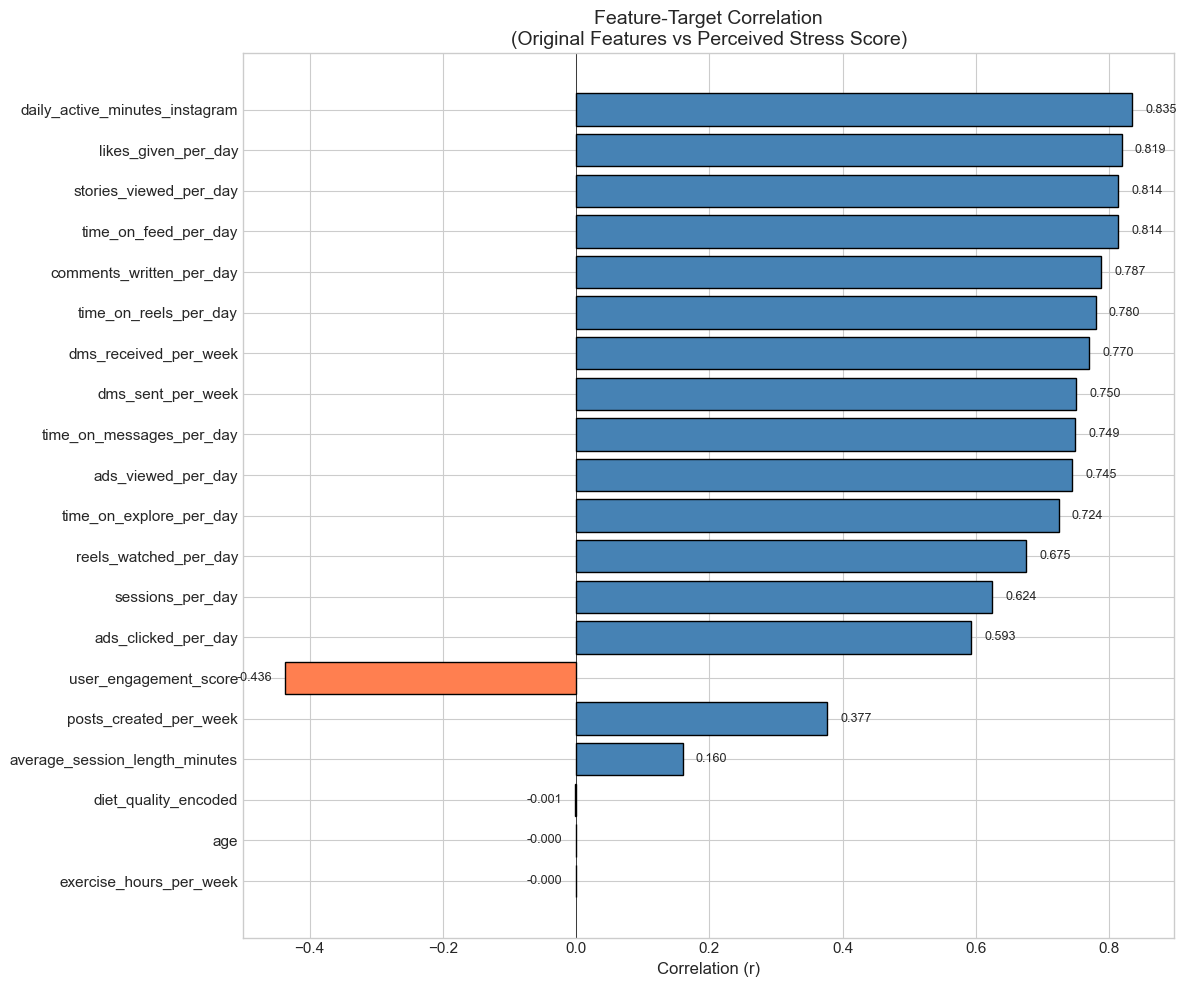

In [22]:
# Visualize feature-target correlations
fig, ax = plt.subplots(figsize=(12, 10))

# Sort for visualization
feat_sorted = feat_corr_df_sorted.copy()
colors = ['steelblue' if r >= 0 else 'coral' for r in feat_sorted['r']]

y_pos = np.arange(len(feat_sorted))
ax.barh(y_pos, feat_sorted['r'], color=colors, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_sorted['Feature'])
ax.set_xlabel('Correlation (r)', fontsize=12)
ax.set_title('Feature-Target Correlation\n(Original Features vs Perceived Stress Score)', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()

# Add correlation values as text
for i, (_, row) in enumerate(feat_sorted.iterrows()):
    x_pos = row['r'] + 0.02 if row['r'] >= 0 else row['r'] - 0.02
    ha = 'left' if row['r'] >= 0 else 'right'
    ax.text(x_pos, i, f"{row['r']:.3f}", va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('feature_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Linear Regression Using Principal Components

Perform regression using principal components to predict the target variable.

In [23]:
# Regression using all PCs
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split data
X_pc_train, X_pc_test, y_train, y_test = train_test_split(
    X_pc, y, test_size=0.2, random_state=42
)

# Fit linear regression on PC space
lr_pc = LinearRegression()
lr_pc.fit(X_pc_train, y_train)

# Predict
y_pred = lr_pc.predict(X_pc_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression in Principal Component Space:")
print("=" * 50)
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"\nThis R² represents the linear relationship between")
print(f"all {len(eigenvalues)} principal components and perceived_stress_score.")

Linear Regression in Principal Component Space:
  R² Score: 0.7286
  RMSE: 6.1697

This R² represents the linear relationship between
all 20 principal components and perceived_stress_score.


In [24]:
# Analyze regression coefficients in PC space
print("\nRegression Coefficients in PC Space:")
print("=" * 50)
print(f"{'PC':<8} {'Coefficient':<15} {'Eigenvalue':<15}")
print("-" * 50)

for i, (coef, ev) in enumerate(zip(lr_pc.coef_, eigenvalues)):
    print(f"PC{i+1:<6} {coef:<15.4f} {ev:<15.4f}")


Regression Coefficients in PC Space:
PC       Coefficient     Eigenvalue     
--------------------------------------------------
PC1      2.7633          12.2681        
PC2      -0.3300         1.3965         
PC3      1.9983          1.3123         
PC4      0.0105          1.0006         
PC5      0.0005          0.9994         
PC6      1.2218          0.6438         
PC7      0.9269          0.4817         
PC8      -0.5369         0.4358         
PC9      -0.4068         0.2395         
PC10     -0.1616         0.2014         
PC11     0.0493          0.1929         
PC12     -0.9095         0.1717         
PC13     -0.7853         0.1410         
PC14     0.8511          0.1215         
PC15     1.5673          0.1057         
PC16     -0.6905         0.0988         
PC17     -1.4136         0.0746         
PC18     0.1871          0.0634         
PC19     -0.5356         0.0423         
PC20     7.3359          0.0087         


In [25]:
# Incremental R² analysis: How much does each PC add?
print("\nIncremental R² Analysis:")
print("=" * 60)
print(f"{'# PCs':<10} {'R²':<15} {'RMSE':<15} {'Δ R²':<15}")
print("-" * 60)

prev_r2 = 0
incremental_r2 = []

for n_pc in range(1, len(eigenvalues) + 1):
    # Use first n_pc components
    lr_temp = LinearRegression()
    lr_temp.fit(X_pc_train[:, :n_pc], y_train)
    y_pred_temp = lr_temp.predict(X_pc_test[:, :n_pc])
    
    r2_temp = r2_score(y_test, y_pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    delta_r2 = r2_temp - prev_r2
    
    incremental_r2.append({'n_pc': n_pc, 'R2': r2_temp, 'RMSE': rmse_temp, 'Delta_R2': delta_r2})
    print(f"{n_pc:<10} {r2_temp:<15.4f} {rmse_temp:<15.4f} {delta_r2:<+15.4f}")
    
    prev_r2 = r2_temp


Incremental R² Analysis:
# PCs      R²              RMSE            Δ R²           
------------------------------------------------------------
1          0.6694          6.8100          +0.6694        
2          0.6704          6.7995          +0.0010        
3          0.7085          6.3945          +0.0381        
4          0.7085          6.3945          +0.0000        
5          0.7085          6.3945          -0.0000        
6          0.7153          6.3196          +0.0068        
7          0.7183          6.2859          +0.0030        
8          0.7192          6.2761          +0.0009        
9          0.7194          6.2733          +0.0002        
10         0.7195          6.2729          +0.0000        
11         0.7195          6.2728          +0.0000        
12         0.7204          6.2621          +0.0010        
13         0.7211          6.2542          +0.0007        
14         0.7217          6.2476          +0.0006        
15         0.7236          6

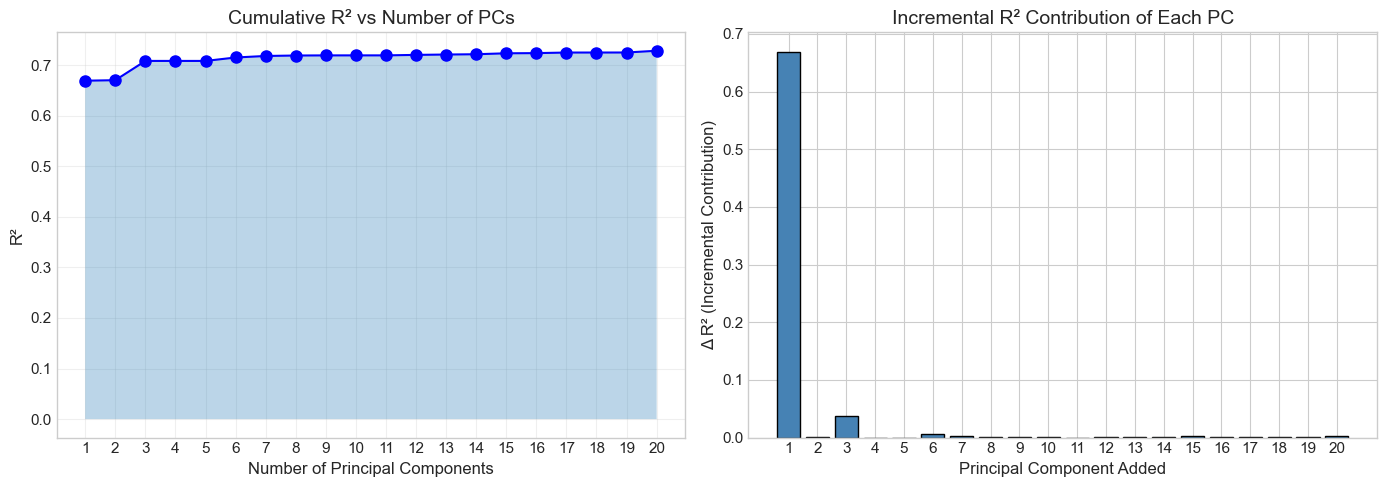

In [26]:
# Visualize incremental R²
inc_r2_df = pd.DataFrame(incremental_r2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative R²
axes[0].plot(inc_r2_df['n_pc'], inc_r2_df['R2'], 'bo-', markersize=8)
axes[0].fill_between(inc_r2_df['n_pc'], 0, inc_r2_df['R2'], alpha=0.3)
axes[0].set_xlabel('Number of Principal Components', fontsize=12)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Cumulative R² vs Number of PCs', fontsize=14)
axes[0].set_xticks(inc_r2_df['n_pc'])
axes[0].grid(True, alpha=0.3)

# Plot 2: Incremental R² (contribution of each PC)
colors = ['steelblue' if d >= 0 else 'coral' for d in inc_r2_df['Delta_R2']]
axes[1].bar(inc_r2_df['n_pc'], inc_r2_df['Delta_R2'], color=colors, edgecolor='black')
axes[1].set_xlabel('Principal Component Added', fontsize=12)
axes[1].set_ylabel('Δ R² (Incremental Contribution)', fontsize=12)
axes[1].set_title('Incremental R² Contribution of Each PC', fontsize=14)
axes[1].set_xticks(inc_r2_df['n_pc'])
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('incremental_r2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Summary and Interpretation

In [27]:
# Create comprehensive summary
print("=" * 70)
print("EIGENVALUE ANALYSIS SUMMARY")
print("=" * 70)

print("\n1. EIGENVALUE DISTRIBUTION:")
print(f"   - Total variance (sum of eigenvalues): {total_variance:.4f}")
print(f"   - Largest eigenvalue (PC1): {eigenvalues[0]:.4f} ({variance_ratio[0]*100:.1f}% variance)")
print(f"   - Smallest eigenvalue (PC{len(eigenvalues)}): {eigenvalues[-1]:.4f} ({variance_ratio[-1]*100:.1f}% variance)")
print(f"   - Components for 80% variance: {n_components_80}")
print(f"   - Components for 90% variance: {n_components_90}")
print(f"   - Components with λ ≥ 1 (Kaiser): {n_kaiser}")

print("\n2. TOP FEATURES CORRELATED WITH STRESS:")
for i, row in feat_corr_df_sorted.head(5).iterrows():
    direction = "↑" if row['r'] > 0 else "↓"
    print(f"   {direction} {row['Feature']}: r = {row['r']:.4f}")

print("\n3. TOP PRINCIPAL COMPONENTS CORRELATED WITH STRESS:")
for _, row in pc_corr_df_sorted.head(5).iterrows():
    direction = "↑" if row['r'] > 0 else "↓"
    print(f"   {direction} {row['PC']}: r = {row['r']:.4f} (R² = {row['R2']:.4f})")

print("\n4. REGRESSION PERFORMANCE:")
print(f"   - Full PC regression R²: {r2:.4f}")
print(f"   - Full PC regression RMSE: {rmse:.4f}")

print("\n" + "=" * 70)

EIGENVALUE ANALYSIS SUMMARY

1. EIGENVALUE DISTRIBUTION:
   - Total variance (sum of eigenvalues): 20.0000
   - Largest eigenvalue (PC1): 12.2681 (61.3% variance)
   - Smallest eigenvalue (PC20): 0.0087 (0.0% variance)
   - Components for 80% variance: 5
   - Components for 90% variance: 7
   - Components with λ ≥ 1 (Kaiser): 4

2. TOP FEATURES CORRELATED WITH STRESS:
   ↑ daily_active_minutes_instagram: r = 0.8345
   ↑ likes_given_per_day: r = 0.8188
   ↑ stories_viewed_per_day: r = 0.8140
   ↑ time_on_feed_per_day: r = 0.8135
   ↑ comments_written_per_day: r = 0.7874

3. TOP PRINCIPAL COMPONENTS CORRELATED WITH STRESS:
   ↑ PC1: r = 0.8181 (R² = 0.6693)
   ↑ PC3: r = 0.1938 (R² = 0.0375)
   ↑ PC6: r = 0.0828 (R² = 0.0069)
   ↑ PC20: r = 0.0581 (R² = 0.0034)
   ↑ PC7: r = 0.0545 (R² = 0.0030)

4. REGRESSION PERFORMANCE:
   - Full PC regression R²: 0.7286
   - Full PC regression RMSE: 6.1697



In [28]:
# Export results
eigenvalue_df.to_csv('eigenvalue_analysis.csv', index=False)
loadings_df.to_csv('eigenvector_loadings.csv')
feat_corr_df_sorted.to_csv('feature_correlations.csv', index=False)
pc_corr_df_sorted.to_csv('pc_correlations.csv', index=False)
inc_r2_df.to_csv('incremental_r2.csv', index=False)

print("Results exported:")
print("  ✓ eigenvalue_analysis.csv")
print("  ✓ eigenvector_loadings.csv")
print("  ✓ feature_correlations.csv")
print("  ✓ pc_correlations.csv")
print("  ✓ incremental_r2.csv")

Results exported:
  ✓ eigenvalue_analysis.csv
  ✓ eigenvector_loadings.csv
  ✓ feature_correlations.csv
  ✓ pc_correlations.csv
  ✓ incremental_r2.csv


---
## 13. Geometric Interpretation

### What the Eigenvalue Analysis Tells Us:

| Concept | Geometric Meaning | Interpretation |
|---------|-------------------|----------------|
| **Eigenvalue (λ)** | Length of axis in data ellipsoid | How much variance in that direction |
| **Eigenvector (v)** | Direction of axis | Which features combine in that direction |
| **Large λ** | Long axis | Important direction with high variance |
| **Small λ** | Short axis | Less important, possibly redundant |
| **λ ≈ 0** | Collapsed axis | Features are linearly dependent |

### Relationship with Linear Regression:

- Principal components that correlate highly with the target are the **most predictive directions**
- These directions combine original features in specific ways (shown by loadings)
- The regression coefficients in PC space show the **contribution of each direction** to prediction

In [ ]:
print("\n" + "=" * 50)
print("Analysis Complete!")
print("=" * 50)